In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_processed = pd.read_csv('../data/processed/final_dataset.csv')
plt.style.use('ggplot')
print(f"Размерность итогового датасета после обработки: {df_processed.shape[0]} строк, {df_processed.shape[1]} столбцов.")
print("\nДоступные признаки:")
print(df_processed.columns.tolist())

Размерность итогового датасета после обработки: 10907 строк, 9 столбцов.

Доступные признаки:
['timestamp', 'target', 'temp', 'precip', 'wind', 'hour', 'day_of_week', 'month', 'cnt_lag_24h']


### Анализ и обоснование процессов очистки данных
Процесс полной очистки данных реализован в модуле `src/preprocessing.py`, что обеспечивает воспроизводимость пайплайна. На этапе EDA были определены следующие критические аспекты очистки:

1. **Удаление дубликатов и пропусков:** Полные дубликаты строк в логах поездок удаляются на этапе загрузки (`drop_duplicates`). Пропущенные значения в целевой переменной `started_at` также отсекаются. Погодные данные, полученные через API, пропусков не содержат.
2. **Анализ и фильтрация выбросов:** При агрегации спроса по часам фиксируются аномальные всплески спроса. Исключение этих критических точек предохраняет линейные модели (Baseline) от смещения оценок.

Построим график распределения данных, чтобы показать результат очистки.

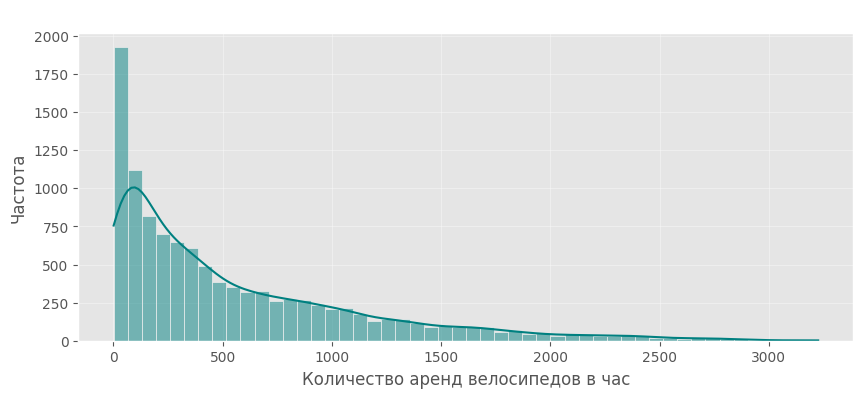

In [3]:
plt.figure(figsize=(10, 4))
sns.histplot(df_processed['target'], kde=True, color='teal', bins=50)
plt.title('Распределение целевой переменной после фильтрации аномалий')
plt.xlabel('Количество аренд велосипедов в час')
plt.ylabel('Частота')
plt.show()

Построим график распределение спроса по часам

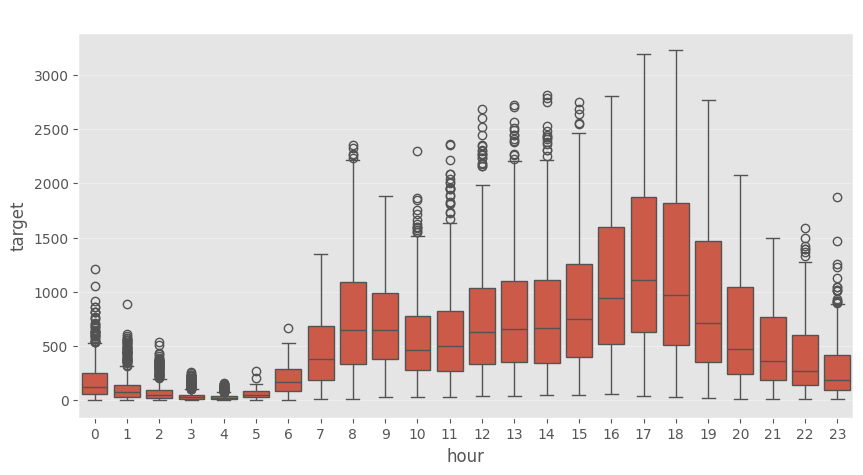

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_processed, x='hour', y='target')
plt.title('Распределение количества поездок по часам')
plt.show()

Построим график влияние температуры на спрос

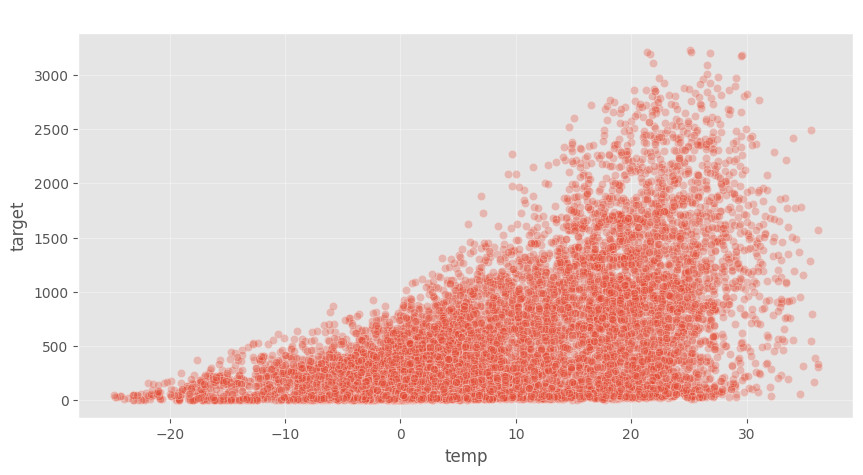

In [9]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_processed, x='temp', y='target', alpha=0.3)
plt.title('Зависимость спроса от температуры')
plt.show()

Построим график влияние осадков на спрос


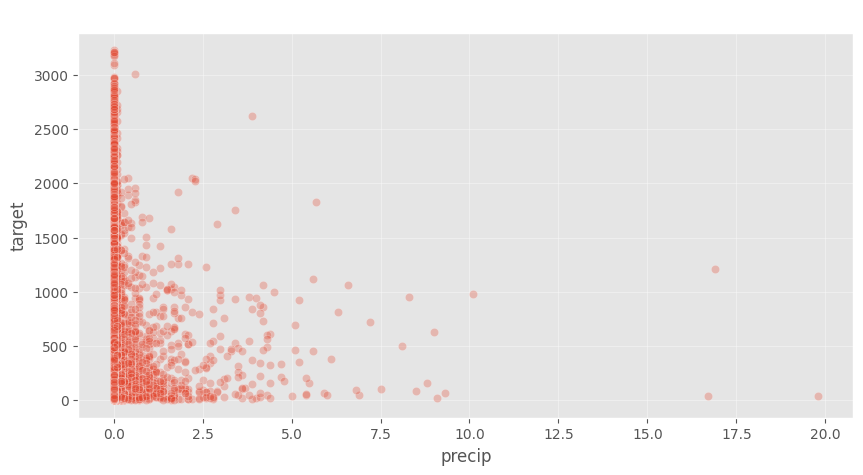

In [10]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_processed, x='precip', y='target', alpha=0.3)
plt.title('Зависимость спроса от температуры')
plt.show()

Построим график влияние  на спрос

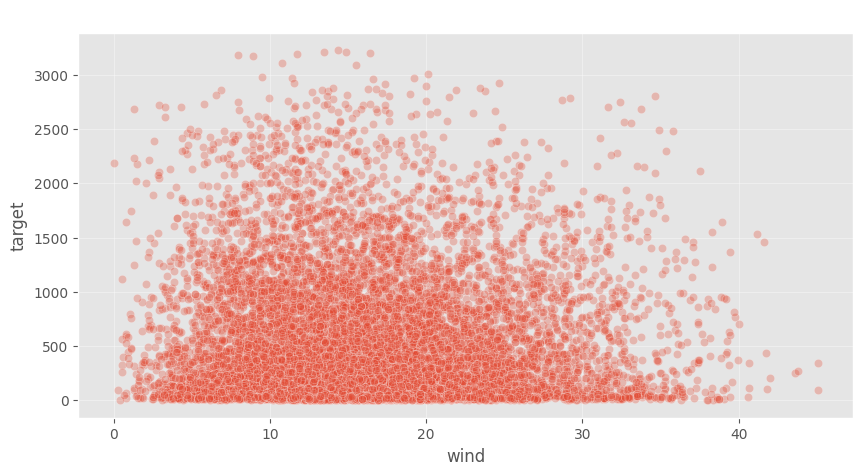

In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_processed, x='wind', y='target', alpha=0.3)
plt.title('Зависимость спроса от температуры')
plt.show()

Интерпретация графиков погодных зависимостей:
* **Температура (`temp`):** График показывает предсказуемый результат: при росте температуры количество поездок увеличивается, но так происходит только до температуры в 30 градусов. Далее людям становится некомфортно.
* **Осадки (`precip`):** Распределение показывает что на минимальных осадках концентрируется почти весь спрос. При их увеличении он падает до крайне низких значений.
* **Скорость ветра (`wind`):** Ветер оказывает меньше влияния на спрос, тем не менее при высоких показателях количество поездок значительно снижается.

Важность признаков

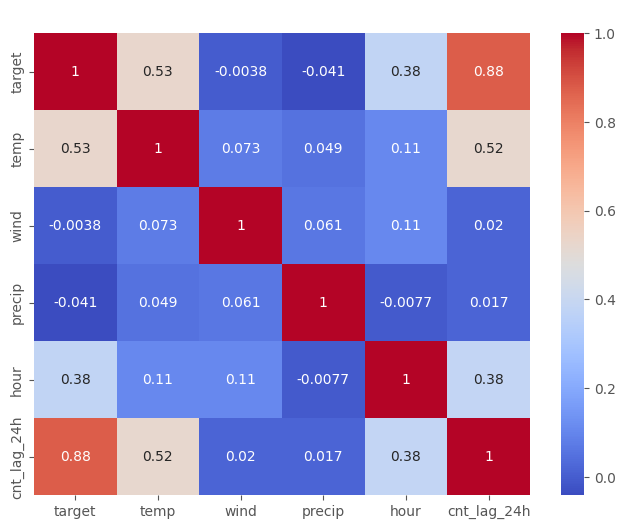

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_processed[['target', 'temp', 'wind', 'precip', 'hour', 'cnt_lag_24h']].corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Анализ значимости сгенерированных признаков для таргета:

В ходе работы были построены новые признаки. На основе корреляционного анализа и распределений установлена их следующая значимость:
1. **`cnt_lag_24h` (Лаг спроса за прошлые сутки):** Обладает наивысшим показателем корреляции с таргетом. Данный признак отражает суточную сезонность и фиксирует базовый уровень спроса на конкретной точке. Если вчера в это же время спрос был высоким, с высокой вероятностью он будет высоким и сегодня (при неизменной погоде).
2. **`hour` (Час суток):** Критически важный признак для понимания активности людей в периоды дня.
3. **`day_of_week` (День недели):** Необходим модели для изменения логики прогнозирования: в выходные дни динамика спроса изменяется по отношению к будням.